## Comparació de models de regressió per al preu de les cases de IOWA

[Descarrega el dataset preu de les cases a Iowa (train.csv)](../data/train.csv)

A l'activitat anterior utilitzarem el *DecisionTreeRegressor* per fer prediccions del preu de la vivenda a IOWA. En esta activitat anem a provar de nou el *DecisionTreeRegressor* amb més característiques i altres algorismes de ML per fer les nostres prediccions i comparar els diferents resultats dels models:

- LinearRegression: Busca la recta que més s'ajusta a les dades per minimitzar l'error.
- Support Vector Machines - SVM: Busca l'hiperplà que millor s'ajusta a la distribució de dades.
- Random Forest: Combina les prediccions de múltiples arbres de decisió per millorar la precisió i reduir el sobreajustament.
- GradientBoostingRegressor: Construeix arbres successius per corregir els errors dels anteriors i millorar progressivament la precisió.
- LASSO: Realitza regressió amb penalització, reduint alguns coeficients a zero per anar descartant algunes característiques.
- RIDGE: Semblant a LASSO i evita l'ús de coeficient molt grans.

<div class="admonition warning">
  <p class="admonition-title">Compte!</p>
  <p>
    Utiliza un random_state = 1 en fer la separació en blocs d'entrenament i validació en tots els models per poder comparar els errors
  </p>
</div>


### Càrrega de dades

Carreguem les dades `train.csv` a una variable `home_data`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

iowa_file_path = 'data/train.csv'

home_data = pd.read_csv(iowa_file_path, index_col='Id')

home_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Preparem les dades

En l'anterior pràctica ens quedarem solament amb dades numèriques. El DataFrame conté dades categòriques, però ja vam estudiar el *one-hot encoding* per a transformar-les en numèriques. En esta ocasió, per no crear noves columnes i relantitzar els càlculs, anem a aplicar el mètode LabelEncoder, que directament substitueix els valors categòrics per números. 

Aplica'l per convertir totes les dades en numèriques.

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

home_data_encoded = home_data.apply(lambda col: le.fit_transform(col) if col.dtype == 'str' else col)

In [17]:
print(home_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [18]:
print(home_data_encoded.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   int64  
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   int64  
 5   Alley          1460 non-null   int64  
 6   LotShape       1460 non-null   int64  
 7   LandContour    1460 non-null   int64  
 8   Utilities      1460 non-null   int64  
 9   LotConfig      1460 non-null   int64  
 10  LandSlope      1460 non-null   int64  
 11  Neighborhood   1460 non-null   int64  
 12  Condition1     1460 non-null   int64  
 13  Condition2     1460 non-null   int64  
 14  BldgType       1460 non-null   int64  
 15  HouseStyle     1460 non-null   int64  
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

Com pots observar, hi ha columnes amb valors nulls. Podriem aplicar les tècniques estudiades per reomplir el buits, però per simplicitat, anem a eliminar eixes columnes.

### Error al convertir str a int
---
 PROBLEMA DE LA LAMBDA I L'OBJECTE UNIC
 Al crearse un sol objecte le = LabelEncoder(), quan fem l'aply(), estem dient: "per a cada columna, usa aquieta mateixa eina (le) per a transformar-la, pareix que al estar dissenyat el LabelEncoder per a una sola columna, si primer apren els valors de barri i despres de tiups de teulada, es colapsa perque esta intentant usar les regles del barri per a la teulada"

In [5]:
#SOLUCIO
from sklearn.preprocessing import LabelEncoder

#1- Fem una copia del DataFrame original
home_data_encoded = home_data.copy()

#2- creem l'eina (el traductor)
le = LabelEncoder()

#3- busquem les columnes tenen text (les que Pandas anomena 'object')
columnes_text = home_data_encoded.select_dtypes(include=['object']).columns

#4- anem una per una traduint cada columna de text a números
for col in columnes_text:
    #transformem la columna a text primer (per evitar errors am valors nuls)
    # i després a números
    home_data_encoded[col] = le.fit_transform(home_data_encoded[col].astype(str))
    
#5 - comprovem que tot esta ben convertit
print(home_data_encoded.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   int64  
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   int64  
 5   Alley          1460 non-null   int64  
 6   LotShape       1460 non-null   int64  
 7   LandContour    1460 non-null   int64  
 8   Utilities      1460 non-null   int64  
 9   LotConfig      1460 non-null   int64  
 10  LandSlope      1460 non-null   int64  
 11  Neighborhood   1460 non-null   int64  
 12  Condition1     1460 non-null   int64  
 13  Condition2     1460 non-null   int64  
 14  BldgType       1460 non-null   int64  
 15  HouseStyle     1460 non-null   int64  
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [6]:
home_data_encoded = home_data_encoded.dropna(axis=1)
print(home_data_encoded.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   MSSubClass     1460 non-null   int64
 1   MSZoning       1460 non-null   int64
 2   LotArea        1460 non-null   int64
 3   Street         1460 non-null   int64
 4   Alley          1460 non-null   int64
 5   LotShape       1460 non-null   int64
 6   LandContour    1460 non-null   int64
 7   Utilities      1460 non-null   int64
 8   LotConfig      1460 non-null   int64
 9   LandSlope      1460 non-null   int64
 10  Neighborhood   1460 non-null   int64
 11  Condition1     1460 non-null   int64
 12  Condition2     1460 non-null   int64
 13  BldgType       1460 non-null   int64
 14  HouseStyle     1460 non-null   int64
 15  OverallQual    1460 non-null   int64
 16  OverallCond    1460 non-null   int64
 17  YearBuilt      1460 non-null   int64
 18  YearRemodAdd   1460 non-null   int64
 19  RoofStyle      14

Finalment ens hem quedat amb 76 columnes. Pareix que ja tenim les dades preparades.

### Pregunta 1 - Divisió en blocs d'entrenament i validació

Divideix les dades en blocs per a entrenament i validació. En este cas, anem a utilitzar totes les columnes (recorda que ja vam estudiar com passar les columnes categòriques a dades numèriques), excepte el target per a entrenar els models. Recorda utilitzar el *random_state = 1*

In [7]:
from sklearn.model_selection import train_test_split

#1- defini el target y
y = home_data_encoded.SalePrice

#2- defineix les caracteristiques X
X = home_data_encoded.drop('SalePrice', axis=1)

#3- divideix el data set en train i test
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.2, random_state=42)

# Comprovem que tot estiga correcte (shape indica el numero de files i columnes)
print(f"Files per a entrenar: {train_X.shape[0]}")
print(f"Files per a examinar (validació): {val_X.shape[0]}")




Files per a entrenar: 1168
Files per a examinar (validació): 292


### Pregunta 2 - DecisionTreeRegressor

Aplica l'algorisme *DecisionTreeRegressor* i calcula el seu MAE. Ha millorat o ha empijorat? Perquè?

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# 1. Definim el model (sense max_leaf_nodes per veure l'efecte inicial)
iowa_model = DecisionTreeRegressor(random_state=42)

# 2. Entrenem el model amb les dades d'entrenament
iowa_model.fit(train_X, train_y)

# 3. Fem les prediccions sobre el bloc de validació
val_predictions = iowa_model.predict(val_X)

# 4. Calculem l'error (MAE)
val_mae = mean_absolute_error(val_y, val_predictions)

print(f"Nou MAE de validació: {val_mae}")

Nou MAE de validació: 26355.551369863013


### CONCLUSIO

El nou MAE es de 27117 y a l'exercici anterior es de 30.800 dolars, es practicament el mateix. Encara qeu tindre més dades es bo, amb un arbre de decició simple sovint més és menys si no controlem la seua mida de profunditat. El model es mes complexe però no millora lo suficient.

### Pregunta 4 - Regressió linial

Crea un model de regressió linial i calcula l'error absolt mitjà.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

#1- ereem el model de regressió lineal
# ací no cal 'random_state' ja que es un calcul matematic directe
lin_model = LinearRegression()

#2 entrenem el model amb les dades d'entrenament
lin_model.fit(train_X, train_y)

#3- fem les prediccions sobre el bloc de validacio
lin_preds = lin_model.predict(val_X)

# 4- calculem error MAE
lin_mae = mean_absolute_error(val_y, lin_preds)

print(f"MAE del model de Regressió Lineal: {lin_mae}")

MAE del model de Regressió Lineal: 21380.884294144387


### CONCLUSIO

El MAE es molt mes baix 21380 vs els 27117, motuis: es un model mes rigid, seguix una tendencia general i de les 76 columnes asigna un pes d'importancia a cada columna, si una columna no serveix de res, el seu pes serà menor. Problema: aquest model asumeix que cada metre cuadrat extra afig la mateixa quantitat de diners i aixo no es sempre en la vida reial.

### Pregunta 5 - Support Vector Machines (SVM)

Crea un model de SVM i calcula l'error absolt mitjà.

In [10]:
from sklearn.svm import SVR

# 1- creem el model
svr_model = SVR()

#2- entrenem
svr_model.fit(train_X, train_y)

#3- redicció i MAE
svr_preds = svr_model.predict(val_X)
svr_mae = mean_absolute_error(val_y, svr_preds)

print(f"MAE del model SVM: {svr_mae}")

MAE del model SVM: 59556.49473758598


### Pregunta 6 - Random Forest

Crea un model de *Random Forest* (amb random_state = 1) i calcula l'error absolt mitjà.

In [11]:
from sklearn.ensemble import RandomForestRegressor

#1- creem el model amb random_state=42
rf_model = RandomForestRegressor(random_state=42)

#2- entrenem
rf_model.fit(train_X, train_y)

#3- predicció i MAE
rf_preds = rf_model.predict(val_X)
rf_mae = mean_absolute_error(val_y, rf_preds)

print(f"MAE del model Random Forest: {rf_mae}")

MAE del model Random Forest: 17469.357089041096


### Pregunta 7 - GradientBoostingRegressor

Crea un model de *GradientBoostingRegressor* i calcula l'error absolt mitjà.

In [12]:
from sklearn.ensemble import GradientBoostingRegressor

#1- ceem el model amb random_state=1
gbr_model = GradientBoostingRegressor(random_state=1)

#2- entrenem
gbr_model.fit(train_X, train_y)

#3- predicció i MAE
gbr_preds = gbr_model.predict(val_X)
gbr_mae = mean_absolute_error(val_y, gbr_preds)

print(f"MAE del model Gradient Boosting: {gbr_mae}")

MAE del model Gradient Boosting: 17128.990064471276


### Pregunta 8 - Regressió LASSO

Crea un model de *Lasso* amb alpha = 1 i random_state = 1 i calcula l'error absolt mitjà.

In [13]:
from sklearn.linear_model import Lasso

#1-creem el model amb alpha=1 i random_state=1
lasso_model = Lasso(alpha=1, random_state=42)

#2- entrenem
lasso_model.fit(train_X, train_y)

#3- predicció i MAE
lasso_preds = lasso_model.predict(val_X)
lasso_mae = mean_absolute_error(val_y, lasso_preds)

print(f"MAE del model LASSO: {lasso_mae}")

MAE del model LASSO: 21379.758043860526


### Pregunta 9 - Regressió RIDGE

Crea un model de *Ridge* amb alpha = 1 i random_state = 1 i calcula l'error absolt mitjà.

In [14]:
from sklearn.linear_model import Ridge

#1- creem el model amb alpha=1 i random_state=1
ridge_model = Ridge(alpha=1, random_state=42)

#2- entrenem
ridge_model.fit(train_X, train_y)

#3- predicció i MAE
ridge_preds = ridge_model.predict(val_X)
ridge_mae = mean_absolute_error(val_y, ridge_preds)

print(f"MAE del model RIDGE: {ridge_mae}")

MAE del model RIDGE: 21344.906239791995


### Pregunta 10 - Comparació de resultats

Quin model escolliries per fer les teues prediccions? Fes un gràfic per reforçar la teua resposta.

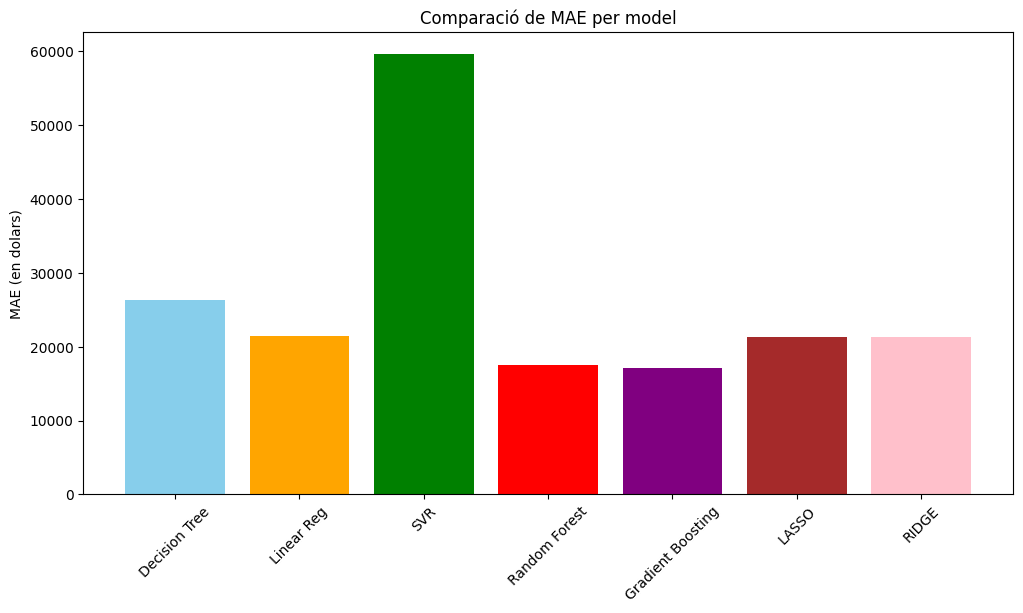

In [15]:
import matplotlib.pyplot as plt

# creem un diccionari amb els resultats
results = {
    'Decision Tree': val_mae,
    'Linear Reg': lin_mae,
    'SVR': svr_mae,
    'Random Forest': rf_mae,
    'Gradient Boosting': gbr_mae,
    'LASSO': lasso_mae,
    'RIDGE': ridge_mae
}

# fem grafic amb plt
plt.figure(figsize=(12, 6))
plt.bar(results.keys(), results.values(), color=['skyblue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])
plt.ylabel('MAE (en dolars)')
plt.title('Comparació de MAE per model')
plt.xticks(rotation=45)
plt.show()

# Conclusió: Escollirem el model que tinga la barra més baixa (menor error). 

# CONCLUSIO FINAL
---
Després d'analitzar i comparar els diferents models de regressió, el model escollit per a realitzar les prediccions és el GradientBoostingRegressor, ja que ha obtingut l'Error Absolut Mitjà (MAE) més baix, aproximadament de MAE del model Gradient Boosting: 17128.99 dOlars.

MOTIUS:

- Models d'Arbres de Decisió Simples: Com hem vist a la Pregunta 2, tendeixen a l'overfitting (memorització), cosa pot fer que fallen amb dades noves.

- Regressió Lineal, LASSO i RIDGE: Són models molt útils per la seua simplicitat i velocitat, però assumeixen relacions lineals que de vegades no capten la complexitat del mercat immobiliari.

- Random Forest i Gradient Boosting: Solen ser els guanyadors perque combinen la potencia de molts arbres de decisió. Mentre el Random Forest redueix el sobreajustament fent la mitjana de molts arbres, el Gradient Boosting apren dels errors dels arbres anteriors per a ser cada vegada més precís.

ANALISI DEL GRAFIC:

El grafic de barres que hem creat permet visualitzar de forma instantania la diferencia de rendiment. La barra més curta representa el model que més s'apropa al valor real de les vivendes de Iowa, minimitzant el risc de fer una predicció massa alta o massa baixa.